In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#to understand why we need to explode method
# let's create a fake list with job skills

data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

df_skills = pd.DataFrame(data)

df_skills

,job_title_short,job_skills
0,Data Analyst,"[excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


In [ ]:
#using explode to expound, every single value on the list gets its own row
df_skills.explode('job_skills')

,job_title_short,job_skills
0,Data Analyst,excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


In [ ]:
#you can afterwards do a quick count of the unique job skills
df_skills.explode('job_skills').value_counts('job_skills')

job_skills
python     3
excel      1
sql        1
r          1
aws        1
airflow    1
Name: count, dtype: int64

<Axes: xlabel='job_skills'>

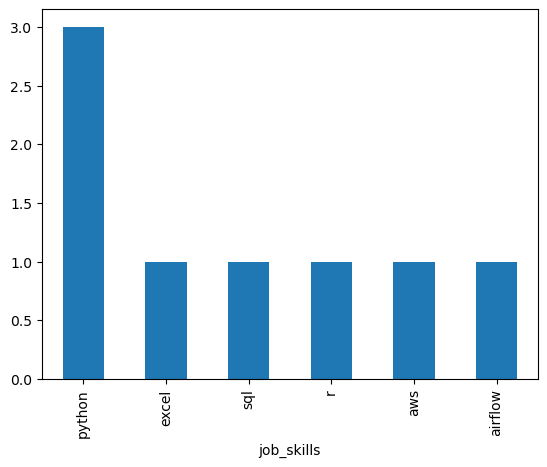

In [6]:
#you can go a step further and plot afterward doing a quick count of the unique job skills
df_skills.explode('job_skills').value_counts('job_skills').plot(kind = 'bar')

Example

Let's transform the list like elements in the job_skills column to a row using the explode() function. This will make it so each skill will have its own row and we'll save this into a new DataFrame called df_exploded.

In [8]:
# Convert string representation to actual list, checking for NaN values first
import ast

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df[['job_title_short', 'job_skills']].head(5)

,job_title_short,job_skills
0,Senior Data Engineer,NaN
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [9]:
# Explode 'job_skills' so each skill gets its own row
df_exploded = df.explode('job_skills')

#Now looking at our new column
df_exploded['job_skills']

0                NaN
1                  r
1             python
1                sql
1              nosql
             ...    
785739         kafka
785739    kubernetes
785739        docker
785740           aws
785740          flow
Name: job_skills, Length: 3777320, dtype: str

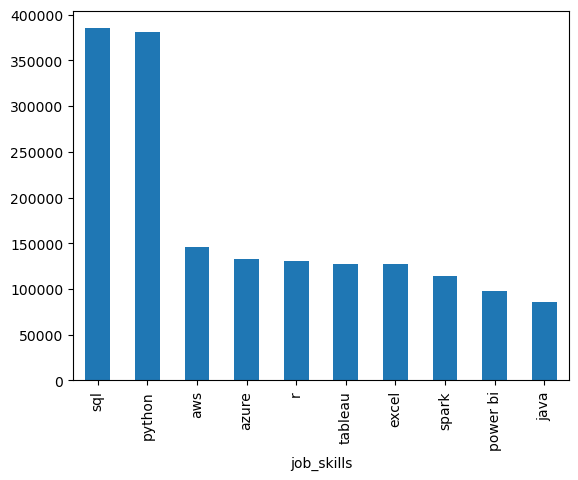

In [10]:
#And now let's visualize it by getting the value_counts() of each skill.
df_exploded['job_skills'].value_counts().head(10).plot(kind='bar')
plt.show()

Calculate Skill count

In [20]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()

In [21]:
#convert skills_count from series to a dataframe
df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count

,job_title_short,job_skills,skill_count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120
...,...,...,...
2251,Software Engineer,wrike,4
2252,Software Engineer,wsl,13
2253,Software Engineer,xamarin,35
2254,Software Engineer,yarn,145


In [23]:
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [24]:
#To plot the top 10 skills for Data analysts

job_title = 'Data Analyst'
top_skills = 10

df_skill_final = df_skills_count[df_skills_count['job_title_short']==job_title].head(top_skills)
df_skill_final

,job_title_short,job_skills,skill_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


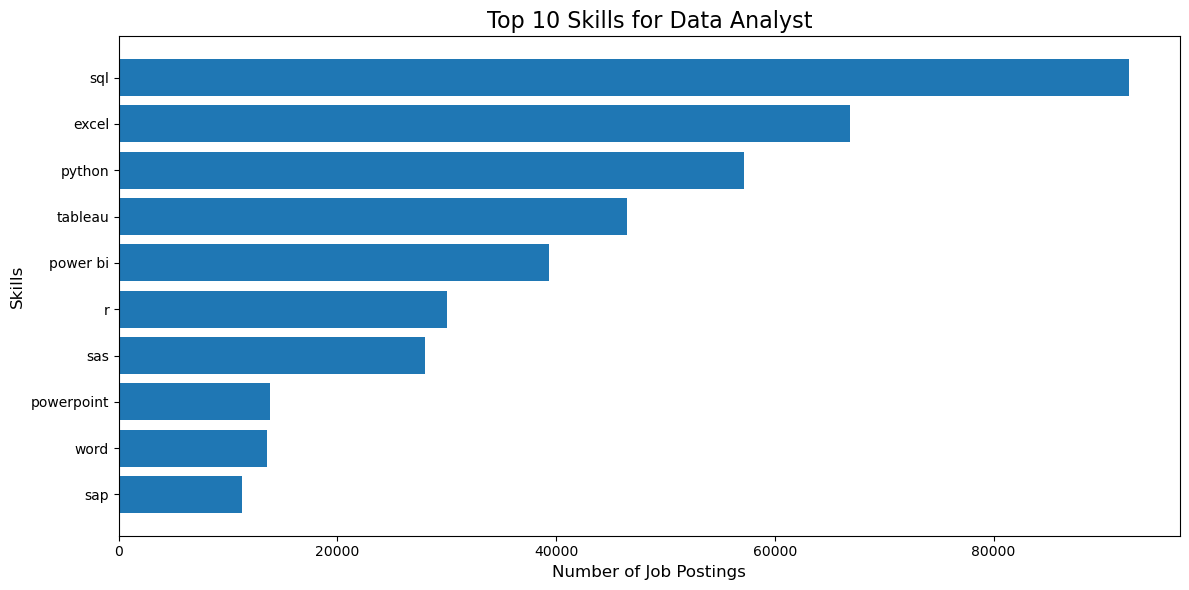

In [28]:
# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
plt.barh(df_skill_final['job_skills'], df_skill_final['skill_count'])
plt.title(f'Top {top_skills} Skills for {job_title}', fontsize=16)
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Skills', fontsize=12)
plt.gca().invert_yaxis()  # Put highest skill at top
plt.tight_layout()
plt.show()